# Constraints: equalities, derived parameters and inequalities

Real samples rarely consist of fully independent parameters: layers grown in the same process share a roughness, a film has a known total thickness, or physics dictates an ordering such as $t_\mathrm{head} < t_\mathrm{tail}$.
`easyreflectometry` offers three kinds of constraints to express this, and they survive saving and reloading a project (the one exception — a standalone `derived_parameter` — is called out below):

1. **Equality constraints** (dependencies) — a parameter follows an expression of other parameters and leaves the fit: `constrain`, `constrain_equal`, `unconstrain`.
2. **Derived read-only parameters** — live calculations such as `Model.total_thickness` or your own `derived_parameter`; they can be referenced from other constraints, and `constrain_to_sum` uses them to keep a total fixed while the split is fitted.
3. **Inequality constraints** — `t_A < t_B` or `t_A + t_B < 90` declared on the project and *enforced during fitting* as penalties on the BUMPS fit problem. Only the BUMPS minimizers (and the DREAM sampler) support them; LMFit and DFO-LS refuse with a clear error rather than silently ignoring physics.

In this tutorial we build a simple two-layer film, visualize it, apply each kind of constraint, and run an inequality-constrained fit on simulated data whose *true* answer violates the constraint — so we can watch the fit land exactly on the boundary of the allowed region.

First configure matplotlib to place figures in the notebook and import the needed modules.

In [1]:
%matplotlib inline

In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
from easyscience import global_object
from easyscience.fitting import AvailableMinimizers

from easyreflectometry import InequalitySpec
from easyreflectometry import Project
from easyreflectometry import UnitError
from easyreflectometry import clamp_sum_partners
from easyreflectometry import constrain
from easyreflectometry import constrain_to_sum
from easyreflectometry import derived_parameter
from easyreflectometry import is_constrained_to_sum
from easyreflectometry import restore_sum_partners
from easyreflectometry import unconstrain
from easyreflectometry.data import DataSet1D
from easyreflectometry.sample import Layer
from easyreflectometry.sample import Material
from easyreflectometry.sample import Multilayer

## Building the sample

We start from a default project and replace its film with two layers on a silicon substrate:

| | material | SLD (10⁻⁶ Å⁻²) | thickness (Å) |
|---|---|---|---|
| superphase | vacuum | 0.0 | ∞ |
| film A | MatA | 3.0 | 40 |
| film B | MatB | 5.0 | 60 |
| subphase | Si | 2.07 | ∞ |

In [3]:
project = Project()
project.default_model()
model = project.models[0]

film_a = Multilayer(Layer(Material(3.0, 0.0, 'MatA'), thickness=40.0, roughness=3.0, name='A'), name='Film A')
film_b = Multilayer(Layer(Material(5.0, 0.0, 'MatB'), thickness=60.0, roughness=3.0, name='B'), name='Film B')
substrate = model.sample[-1]
model.remove_assembly(len(model.sample) - 1)  # drop the default D2O / Si pair ...
model.remove_assembly(len(model.sample) - 1)
model.add_assemblies(film_a, film_b, substrate)  # ... and insert our film

t_a = film_a.layers[0].thickness
t_b = film_b.layers[0].thickness
[layer.name for assembly in model.sample for layer in assembly.layers]

['Vacuum Layer', 'A', 'B', 'Si Layer']

To make the discussion easier to follow we define a small helper that draws the sample twice: as a **layer stack** (the beam arrives from the top; hatched media are semi-infinite) and as the corresponding **SLD profile** computed by the calculator. We will call it after every change so the effect of each constraint is visible.

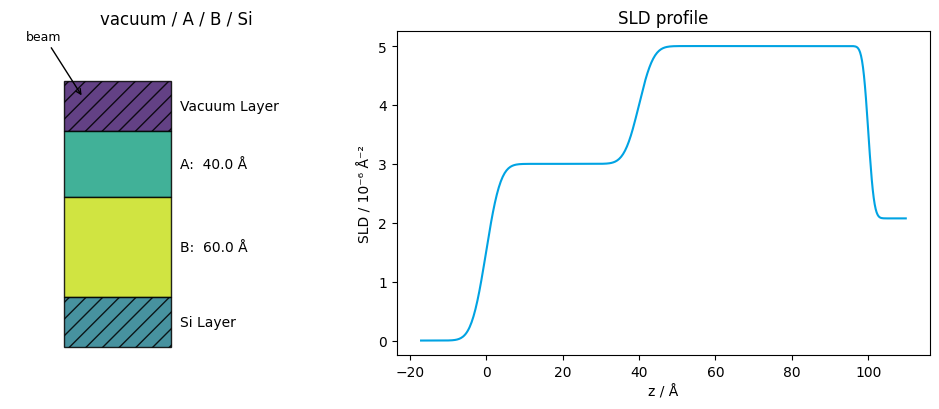

In [4]:
def show_sample(model, title='Sample'):
    """Draw the layer stack (left) and the SLD profile (right)."""
    layers = [layer for assembly in model.sample for layer in assembly.layers]
    fig, (ax_stack, ax_sld) = plt.subplots(1, 2, figsize=(9.5, 4.2), width_ratios=[1.0, 1.6])

    slds = [layer.material.sld.value for layer in layers]
    norm = plt.Normalize(min(slds) - 0.5, max(slds) + 0.5)
    cmap = plt.get_cmap('viridis')
    semi_infinite = 30.0  # display height of the semi-infinite media

    depth = 0.0
    for index, layer in enumerate(layers):
        is_medium = index in (0, len(layers) - 1)
        thickness = layer.thickness.value
        height = semi_infinite if is_medium or thickness <= 0 else thickness
        ax_stack.add_patch(
            plt.Rectangle(
                (0.0, -depth - height),
                1.0,
                height,
                facecolor=cmap(norm(layer.material.sld.value)),
                edgecolor='black',
                hatch='//' if is_medium else None,
                alpha=0.85,
            )
        )
        label = layer.name if is_medium else f'{layer.name}:  {thickness:.1f} Å'
        ax_stack.text(1.08, -depth - height / 2, label, va='center', fontsize=10)
        depth += height
    ax_stack.annotate('beam', xy=(0.18, -10), xytext=(-0.35, 25), fontsize=9, arrowprops={'arrowstyle': '->'})
    ax_stack.set_xlim(-0.5, 2.6)
    ax_stack.set_ylim(-depth - 5, 30)
    ax_stack.axis('off')
    ax_stack.set_title(title)

    z, sld = model.interface().sld_profile(model.unique_name)
    ax_sld.plot(z, sld, color='#00a3e3')
    ax_sld.set_xlabel('z / Å')
    ax_sld.set_ylabel('SLD / 10⁻⁶ Å⁻²')
    ax_sld.set_title('SLD profile')
    plt.tight_layout()
    plt.show()


show_sample(model, 'vacuum / A / B / Si')

## 1. Equality constraints

An equality constraint ties a parameter to an expression of other parameters.
The constrained parameter becomes *dependent*: it is removed from the free fit parameters, follows the expression whenever any input changes, and cannot be set directly.
Here the roughness of film B is tied to 1.5× the roughness of film A:

In [5]:
r_a = film_a.layers[0].roughness
r_b = film_b.layers[0].roughness

constrain(r_b, '1.5 * r', r=r_a)
print(f'r_A = {r_a.value:g} Å  ->  r_B = {r_b.value:g} Å   (r_B independent: {r_b.independent})')

r_a.value = 4.0
print(f'r_A = {r_a.value:g} Å  ->  r_B = {r_b.value:g} Å   (follows automatically)')

r_A = 3 Å  ->  r_B = 4.5 Å   (r_B independent: False)
r_A = 4 Å  ->  r_B = 6 Å   (follows automatically)


`unconstrain` releases the parameter again; it keeps its last value and becomes fittable:

In [6]:
unconstrain(r_b)
print(f'after unconstrain: r_B = {r_b.value:g} Å, independent = {r_b.independent}')

after unconstrain: r_B = 6 Å, independent = True


## 2. Derived read-only parameters

Every model owns `total_thickness`: a read-only parameter equal to the summed thickness of the layers between the superphase and the substrate.
It updates whenever a layer thickness — or the layer structure itself — changes, never enters a fit, and can be used inside other constraint expressions.

In [7]:
total = model.total_thickness
print(f'total film thickness = {total.value:g} Å')

t_a.value = 45.0
print(f'after t_A -> 45 Å:     {total.value:g} Å')

try:
    total.value = 1.0
except AttributeError as error:
    print(f'setting it fails as expected: {error}')

t_a.value = 40.0

total film thickness = 100 Å
after t_A -> 45 Å:     105 Å
setting it fails as expected: This is a dependent parameter, its value cannot be set directly.


`derived_parameter` builds your own live calculations from any parameters. It is **session-only**: it belongs to no model, so it has no structural path — it cannot be named in an inequality constraint, and a project whose equality constraints depend on one cannot be saved. Use a model-owned value such as `Model.total_thickness` when persistence matters.

In [8]:
contrast = derived_parameter(
    'sld_contrast',
    'b - a',
    a=film_a.layers[0].material.sld,
    b=film_b.layers[0].material.sld,
)
print(f'derived SLD contrast (B - A) = {contrast.value:g} {contrast.unit}')

derived SLD contrast (B - A) = 2 1/Å^2


### Keeping a total fixed while fitting the split

`constrain_to_sum` is the classic use of a derived quantity: keep $t_A + t_B$ fixed while the individual thicknesses vary.
The last parameter becomes dependent and absorbs whatever the others change by — watch the stack keep its total height as $t_A$ moves:

t_A = 30, t_B = 70, sum = 100


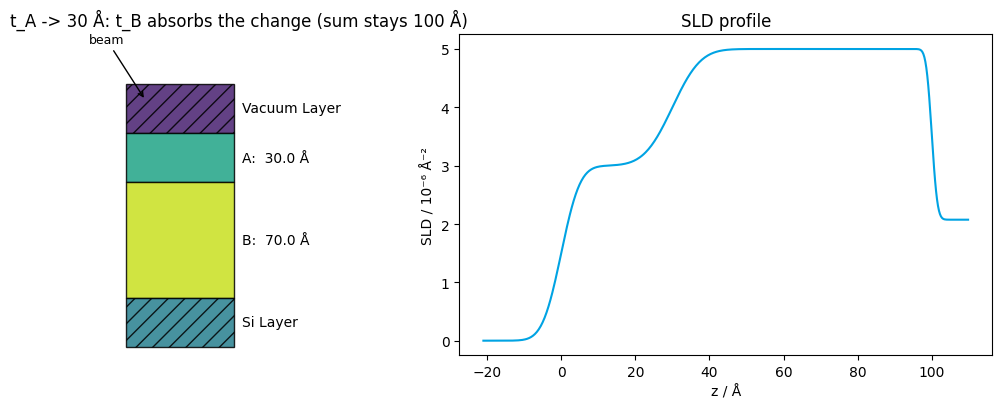

t_A = 70, t_B = 30, sum = 100


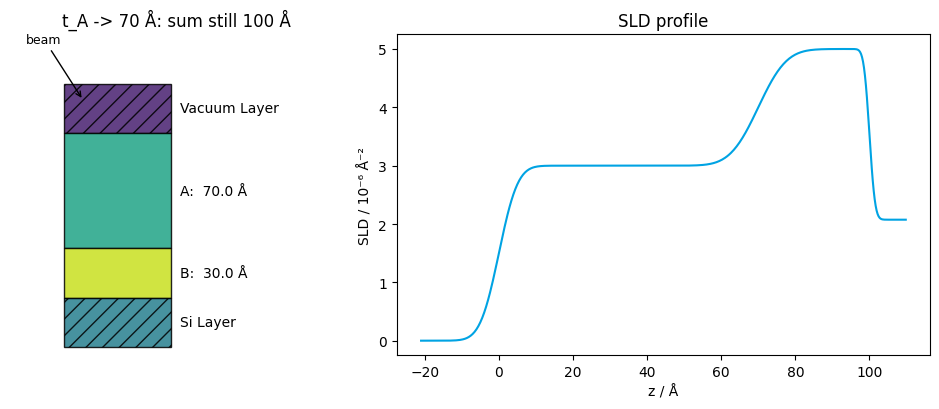

In [9]:
constrain_to_sum(t_b, [t_a, t_b], total=100.0)

t_a.value = 30.0
print(f't_A = {t_a.value:g}, t_B = {t_b.value:g}, sum = {t_a.value + t_b.value:g}')
show_sample(model, 't_A -> 30 Å: t_B absorbs the change (sum stays 100 Å)')

t_a.value = 70.0
print(f't_A = {t_a.value:g}, t_B = {t_b.value:g}, sum = {t_a.value + t_b.value:g}')
show_sample(model, 't_A -> 70 Å: sum still 100 Å')

### Keeping the remainder non-negative

The tied parameter absorbs whatever the others leave over, and nothing in the constraint itself stops a fit from pushing the free partners past the total — which drives the remainder negative, i.e. a layer of negative thickness:


In [10]:
t_a.value = 130.0  # a minimizer step past the 100 Å total
print(f'unguarded: t_A = {t_a.value:g} Å, t_B = {t_b.value:g} Å   <- a negative layer')

unguarded: t_A = 130 Å, t_B = -30 Å   <- a negative layer


`clamp_sum_partners` closes that door: it narrows each partner's upper bound to the headroom it actually has, sharing the slack in proportion to the current values.
`restore_sum_partners` hands the original bounds back when the constraint is released, and `is_constrained_to_sum` reports whether a parameter carries such a constraint — also for one restored from a project file.
The stashed bounds are written to the project file too, so the guard survives a save/load cycle.


In [11]:
print(f'is_constrained_to_sum(t_B) = {is_constrained_to_sum(t_b, [t_a, t_b])}')

t_a.value = 70.0  # back to a sensible split
clamp_sum_partners([t_a], remainder=float(t_b.value))
print(f'clamped  : t_A max = {t_a.max:g} Å (its share of the budget)')

t_a.value = 130.0  # the same step, now refused by the bound
print(f'guarded  : t_A = {t_a.value:g} Å, t_B = {t_b.value:g} Å   <- stops at zero instead')

is_constrained_to_sum(t_B) = True
clamped  : t_A max = 100 Å (its share of the budget)
guarded  : t_A = 100 Å, t_B = 0 Å   <- stops at zero instead


In [12]:
# release it again and restore the starting structure
unconstrain(t_b)
restore_sum_partners([t_a])
t_a.value = 40.0
t_b.value = 60.0

## 3. Inequality constraints

Inequalities are different from the dependencies above: **no parameter leaves the fit**.
Instead the constraint is declared on the *project* and translated, at the start of every fit, into a penalty on the BUMPS fit problem.
While the constraint is violated BUMPS skips the model evaluation and adds a penalty that grows with the violation, steering the optimizer back into the allowed region.

Constraints reference parameters by **structural path** (stable across save/load, unlike unique names):

In [13]:
path_a = project.parameter_path(t_a)
path_b = project.parameter_path(t_b)
print(path_a)
print(path_b)

models/0/sample/1/layers/0/thickness
models/0/sample/2/layers/0/thickness


In [14]:
project.add_inequality_constraint(
    InequalitySpec('a', '<', 'b', lhs_paths={'a': path_a}, rhs_paths={'b': path_b}, name='A below B')
)
project.add_inequality_constraint(
    InequalitySpec('a + b', '<', '90', lhs_paths={'a': path_a, 'b': path_b}, rhs_paths={}, name='budget')
)

for spec, evaluation in zip(project.inequality_constraints, project.evaluate_inequality_constraints()):
    status = 'satisfied' if evaluation.satisfied else 'VIOLATED'
    print(f'{spec.name:10s}  {spec!s:12s}  lhs={evaluation.lhs:g}  rhs={evaluation.rhs:g}  {status}')

A below B   a < b         lhs=40  rhs=60  satisfied
budget      a + b < 90    lhs=100  rhs=90  VIOLATED


Expressions are unit-checked when a constraint is registered — comparing a thickness with an SLD is refused with a `UnitError` (a `ValueError`, so older `except ValueError` handlers keep working):


In [15]:
try:
    project.add_inequality_constraint(
        InequalitySpec(
            'a',
            '<',
            's',
            lhs_paths={'a': path_a},
            rhs_paths={'s': project.parameter_path(film_a.layers[0].material.sld)},
        )
    )
except UnitError as error:
    print(error)

Incompatible units in 'a < s': left side is in 'Å', right side in '1/Å^2'.


A fit started from a point that already violates a constraint would begin on the penalty plateau, where only the penalty slope guides the optimizer — so check the start point first.
Our current values ($40 + 60 = 100$) violate the 90 Å budget; we move to a feasible start:

In [16]:
print('violated now:', [spec.name for spec in project.violated_inequality_constraints()])

t_a.value, t_b.value = 30.0, 50.0  # 30 < 50 and 30 + 50 = 80 < 90
print('after moving :', [spec.name for spec in project.violated_inequality_constraints()] or 'none')

violated now: ['budget']
after moving : none


### Simulated data whose true answer violates the budget

We simulate a measurement from $t_A = 45$ Å, $t_B = 55$ Å — a film whose total (100 Å) breaks the 90 Å budget on purpose — and add 5 % noise.
This is the interesting case: the *unconstrained* optimum lies outside the allowed region, so the constrained fit must settle on the boundary.

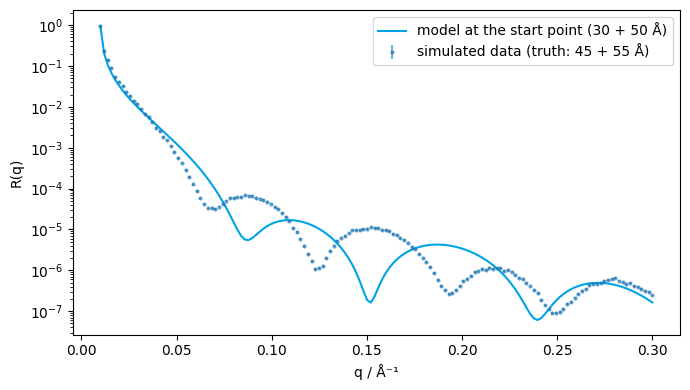

In [17]:
q = np.linspace(0.01, 0.3, 150)

t_a.value, t_b.value = 45.0, 55.0  # the "truth"
r_true = model.interface.fit_func(q, model.unique_name)
rng = np.random.default_rng(42)
r_measured = r_true * rng.normal(1.0, 0.05, size=q.size)
t_a.value, t_b.value = 30.0, 50.0  # back to the feasible start

dataset = DataSet1D(name='simulated', x=q, y=r_measured, ye=(0.05 * r_true) ** 2)

plt.figure(figsize=(7, 4))
plt.errorbar(q, r_measured, yerr=0.05 * r_true, fmt='.', ms=4, alpha=0.6, label='simulated data (truth: 45 + 55 Å)')
plt.plot(q, model.interface.fit_func(q, model.unique_name), color='#00a3e3', label='model at the start point (30 + 50 Å)')
plt.yscale('log')
plt.xlabel('q / Å⁻¹')
plt.ylabel('R(q)')
plt.legend()
plt.tight_layout()
plt.show()

Only the two thicknesses are fitted; everything else stays fixed:

In [18]:
for assembly in model.sample:
    for layer in assembly.layers:
        for parameter in (layer.thickness, layer.roughness, layer.material.sld, layer.material.isld):
            parameter.fixed = True
t_a.fixed = False
t_b.fixed = False
model.scale.fixed = True
model.background.fixed = True

### Engines that cannot enforce inequalities are screened out

Inequality penalties live in the BUMPS fit problem, so they only work with the BUMPS minimizers (and DREAM sampling).
Selecting LMFit with active inequalities raises immediately — physics constraints are never silently dropped:

In [19]:
project.minimizer = AvailableMinimizers.LMFit
try:
    project.fitter.fit_single_data_set_1d(dataset)
except ValueError as error:
    print(error)

CollectionBase is deprecated and will be removed in a future version. Please migrate to ModelBase or EasyList.


Inequality constraints (constraints_factory) require the BUMPS engine; the selected minimizer uses 'lmfit'.


### The constrained fit

With a BUMPS minimizer the project's inequality constraints are picked up automatically:

In [20]:
project.minimizer = AvailableMinimizers.Bumps
result = project.fitter.fit_single_data_set_1d(dataset)

print(f'success = {result.success}')
print('truth (outside the budget):  t_A = 45.00, t_B = 55.00,  sum = 100.00')
print(f'constrained fit:             t_A = {t_a.value:.2f}, t_B = {t_b.value:.2f},  sum = {t_a.value + t_b.value:.2f}')

success = True
truth (outside the budget):  t_A = 45.00, t_B = 55.00,  sum = 100.00
constrained fit:             t_A = 37.78, t_B = 52.22,  sum = 90.00


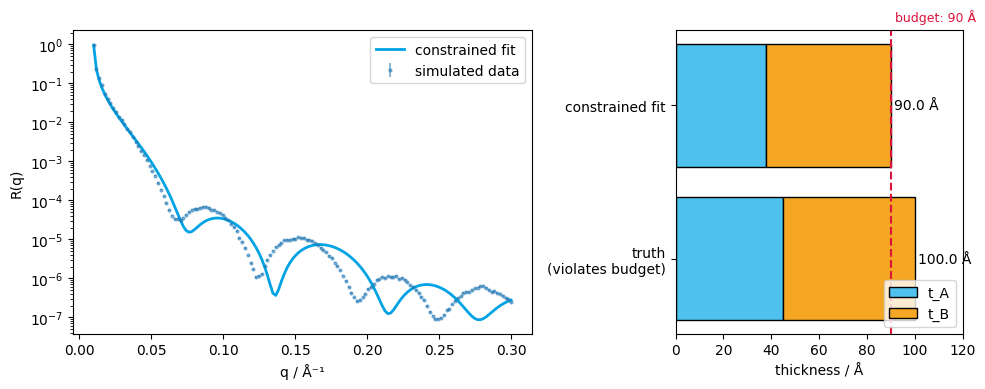

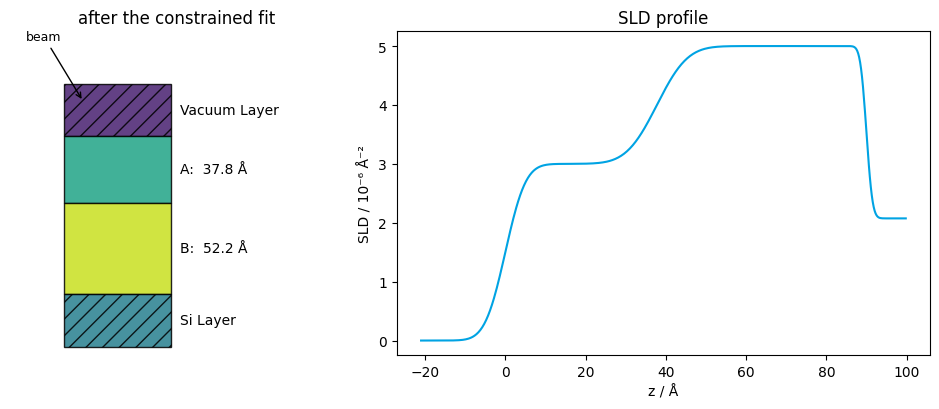

In [21]:
fig, (ax_fit, ax_bars) = plt.subplots(1, 2, figsize=(10, 4), width_ratios=[1.6, 1.0])

ax_fit.errorbar(q, r_measured, yerr=0.05 * r_true, fmt='.', ms=4, alpha=0.5, label='simulated data')
ax_fit.plot(q, model.interface.fit_func(q, model.unique_name), color='#00a3e3', lw=2, label='constrained fit')
ax_fit.set_yscale('log')
ax_fit.set_xlabel('q / Å⁻¹')
ax_fit.set_ylabel('R(q)')
ax_fit.legend()

bars = {
    'truth\n(violates budget)': (45.0, 55.0),
    'constrained fit': (t_a.value, t_b.value),
}
for position, (label, (a_value, b_value)) in enumerate(bars.items()):
    ax_bars.barh(position, a_value, color='#4ec1ef', edgecolor='black', label='t_A' if position == 0 else None)
    ax_bars.barh(position, b_value, left=a_value, color='#f5a623', edgecolor='black', label='t_B' if position == 0 else None)
    ax_bars.text(a_value + b_value + 1.5, position, f'{a_value + b_value:.1f} Å', va='center')
ax_bars.axvline(90.0, color='crimson', ls='--', lw=1.5)
ax_bars.text(90.0, 1.55, ' budget: 90 Å', color='crimson', fontsize=9)
ax_bars.set_yticks(range(len(bars)), bars.keys())
ax_bars.set_xlabel('thickness / Å')
ax_bars.set_xlim(0, 120)
ax_bars.legend(loc='lower right')
plt.tight_layout()
plt.show()

show_sample(model, 'after the constrained fit')

The fit lands **exactly on the boundary** $t_A + t_B = 90$ Å — the closest allowed film to the data — with the ordering $t_A < t_B$ respected as well.

## 4. Save / load

Equality constraints, model-owned derived parameters (such as `total_thickness`) and inequality specs are all part of the project file. A standalone `derived_parameter` is not saved, and a constraint depending on one cannot be either.
We serialize the project to a plain dictionary (this is exactly what `save_as_json` writes), wipe the session, and rebuild:

In [22]:
constrain(r_b, '1.5 * r', r=r_a)  # add the equality constraint again

project_dict = json.loads(json.dumps(project.as_dict()))

global_object.map._clear()  # simulate a fresh Python session
reloaded = Project()
reloaded.from_dict(project_dict)
reloaded_model = reloaded.models[0]

print('inequalities :', [str(spec) for spec in reloaded.inequality_constraints])

reloaded_r_a = reloaded_model.sample[1].layers[0].roughness
reloaded_r_b = reloaded_model.sample[2].layers[0].roughness
reloaded_r_a.value = 6.0
print(f'equality     : r_A = {reloaded_r_a.value:g} -> r_B = {reloaded_r_b.value:g} (still 1.5x)')
print(f'derived      : total_thickness = {reloaded_model.total_thickness.value:g} Å')

CollectionBase is deprecated and will be removed in a future version. Please migrate to ModelBase or EasyList.


inequalities : ['a < b', 'a + b < 90']
equality     : r_A = 6 -> r_B = 9 (still 1.5x)
derived      : total_thickness = 90 Å


## Summary

| constraint | API | enters the fit? | engines |
|---|---|---|---|
| equality (`r_B = 1.5 r_A`) | `constrain`, `constrain_equal`, `unconstrain` | the follower leaves the fit | all |
| derived value (`total_thickness`) | `Model.total_thickness`, `derived_parameter`, `constrain_to_sum` (guard the remainder with `clamp_sum_partners`) | never | all |
| inequality (`t_A + t_B < 90`) | `InequalitySpec` + `Project.add_inequality_constraint` | both parameters stay free; a penalty steers the fit | BUMPS minimizers & DREAM only |

Before fitting a `constrain_to_sum` split, guard the remainder with `clamp_sum_partners` so the partners cannot overrun the total, and give the bounds back with `restore_sum_partners` once the constraint is released.

Useful checks before fitting with inequalities: `project.violated_inequality_constraints()` (feasible start point) and remember that `Bumps_lm` enforces them only weakly (the penalty is spread over the residuals) — prefer `Bumps` (amoeba) or `Bumps_newton`.